In [1]:
! pip install -e .
!pip install geodatasets

Obtaining file:///home/jovyan/Precipitation_paper
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for precip_helper (pyproject.toml) ... done
  Created wheel for precip_helper: filename=precip_helper-0.1.0-0.editable-py3-none-any.whl size=1298 sha256=a6de20f3a19728a6599b76d8d688889c43e9989d721dddb1e5865128df1bf7b6
  Stored in directory: /tmp/pip-ephem-wheel-cache-n573bps_/wheels/0d/d8/f6/0e90ec4164bf3c02bf3bed8ede68ddfb64e3b2ef0023ebb734
Successfully built precip_helper
  Attempting uninstall: precip_helper
    Found existing installation: precip_helper 0.1.0
    Uninstalling precip_helper-0.1.0:
      Successfully uninstalled precip_helper-0.1.0


In [2]:
import xarray as xr
import earthaccess
import boto3
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import warnings
from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd
import rasterio
import datetime
import pyarrow as pa
import pyarrow.parquet as pq
import os
import numpy as np

warnings.filterwarnings('ignore')
%matplotlib inline

%load_ext autoreload
%autoreload 2


from precip_helper.utils import read_in_fires_and_precip

In [3]:
## trying ingest function 
fires = read_in_fires_and_precip()

In [4]:
### Setting plotting parameters

def set_slide_style(aspect_ratio='4:3', base_fontsize=14):
    """
    Configures matplotlib global settings for slide exports.
    """
    # Define standard figure sizes (in inches) based on aspect ratios
    # PowerPoint default widescreen is usually 13.33 x 7.5 inches, 
    # but 10 x 5.625 or 12 x 6.75 scales nicely for matplotlib.
    sizes = {
        '16:9': (12.0, 6.75),
        '4:3':  (10.0, 7.5),
        'square': (8.0, 8.0)
    }
    
    figsize = sizes.get(aspect_ratio, sizes['16:9'])
    
    # Update matplotlib's global rcParams
    plt.rcParams.update({
        # Figure properties
        'figure.figsize': figsize,
        'figure.dpi': 150,           # Good for viewing on screen
        'savefig.dpi': 300,          # High resolution for exporting
        'savefig.bbox': 'tight',     # Removes excess white space around the edge
        'savefig.transparent': True, # Transparent background is often nice for slides
        
        # Font properties
        'font.family': 'sans-serif', # Sans-serif reads better on screens
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': base_fontsize,
        'axes.titlesize': base_fontsize + 4, # Make titles a bit bigger
        'axes.labelsize': base_fontsize + 2,
        'xtick.labelsize': base_fontsize,
        'ytick.labelsize': base_fontsize,
        'legend.fontsize': base_fontsize -8, 
        
        # Line and marker properties
        'lines.linewidth': 2.0,
        'lines.markersize': 8
    })
    
    return figsize

In [5]:
# fires = pd.read_parquet("s3://maap-ops-workspace/shared/zbecker/TESS_fire_spread/sigdeltas_Tess.parq")
# subset_fires = gpd.read_parquet("s3://maap-ops-workspace/shared/zbecker/YANG/large_feds_faf_double_matched.parq")
# subset_fires = subset_fires.to_crs(4326)

# subset_fires["centroid"] = subset_fires.to_crs(4326).centroid
# fires["UfireID"] = fires.mergeid.astype("int").astype("str") + "_" + fires.year.astype("str")
# subset_fires["UfireID"] = subset_fires.mergeid.astype("str") + "_" + subset_fires.year.astype("str")
# subset_fires["polygon"] = subset_fires.geometry
# fires = fires[fires.UfireID.isin(subset_fires[subset_fires.intersectsMTBS == True].UfireID)]
# fname = pd.read_csv("s3://maap-ops-workspace/shared/zbecker/Eli_MTBS_vs_FEDS/v6_output.csv")

# fires = fires.merge(subset_fires[['UfireID', 'centroid', 'polygon']], on = 'UfireID' )
# fires = gpd.GeoDataFrame(fires, geometry = 'polygon')

# def get_st_sp_fire(df, days_after = 7):
#     df.loc[:, "start_time"] = df.t.min()
#     df.loc[:, "end_time"] = df.t.max()
#     df.loc[:, "end_time_plus"] = df.t.astype("datetime64[ns]").max()  + datetime.timedelta(days = days_after)
#     df = df.loc[df.t == df.t.max(), :]
#     return(df)
    
# fires_sm = fires.groupby("UfireID").apply(get_st_sp_fire).reset_index(drop = True)
# fires_sm["stable_index"] = fires_sm.index

In [6]:
# precip = pd.read_parquet(os.path.abspath("IMERG/half_hourly_IMERG_precip"))

In [7]:
# precip = precip.merge(fires_sm[["UfireID",	"centroid"]], on = "UfireID")

# precip.loc[:, "lon"] = precip.centroid.apply(lambda p: p.x)

In [8]:
# precip.loc[:, "offset_hour"] = (precip.lon/15)

# precip.loc[:, "time_lst"] = precip.time_utc.astype("datetime64[ns]") + pd.to_timedelta(precip["offset_hour"], unit='h') #lst_to_utc_offset_hours =  lon/ 15.0

# pm_mask = (precip.time_lst.dt.hour > 6) & (precip.time_lst.dt.hour <= 18) ## correcting to PM 13:30 overpass
# am_mask = (precip.time_lst.dt.hour <= 6) | ((precip.time_lst.dt.hour >= 18))## correcting to AM 1:30 overpass. This is actually an exact  number not a range bc we calcuated it for the extraction. 

# precip.loc[pm_mask, "t"] = precip.loc[pm_mask, "time_lst"].dt.normalize() + pd.Timedelta(hours=12)
# precip.loc[am_mask, "t"] = precip.loc[am_mask, "time_lst"].dt.normalize() + pd.Timedelta(hours=0)





In [9]:
# ## Finding days_since_t
# fires.t = fires.t.astype('datetime64[ns]')
# fires = fires.merge(precip[[ 'precipitation', 'UfireID', 't']], how = 'outer', on = ['UfireID', 't'])

# fires = fires.merge(fires_sm[['UfireID', 'start_time', 'end_time','end_time_plus']], on = 'UfireID')

# # foo = fires[fires.UfireID == "10000_2019"]
# # foo = foo.sort_values(by = "t")
# # foo

In [10]:
# ### adding gaccs, and final fire area and duration

# fires = fires.merge(subset_fires[['n_pixels', 'n_newpixels',
#        'farea', 'duration', 'pixden', 'meanFRP',  'UfireID']], on = 'UfireID')

# gsp = gpd.read_file("/home/jovyan/Preparedness_level/GACC_borders/National_GACC_Boundaries.shp")


# def per_id_constants(df, cols = ["year", "l1_ecoregion", 	"centroid"]):
#     for col in cols:
#         col_val = df.loc[~df[col].isna(), col].iloc[0]
#         df.loc[:, col] = col_val
#     return(df)
# fires = fires.groupby("UfireID").apply(per_id_constants).reset_index(drop = True)

# gsp = gsp.to_crs("EPSG:4326")
# gsp = gsp.dissolve(by='GACCAbbrev').reset_index()

# fires = fires.sjoin(gsp[['GACCName', 'GACCAbbrev','geometry']], how = "left")



# fires = fires.groupby("UfireID").apply(per_id_constants, cols = ["year", "l1_ecoregion", 	"centroid", "farea", 'duration', 'GACCName', 'GACCAbbrev']).reset_index(drop = True)

## Extraction included the precip values from BEFORE the fire's first growth increment

In [11]:
# ## Calculating time offset from ending
# fires['end_time_offset'] =  fires.t.astype("datetime64[ns]") - fires.end_time.astype("datetime64[ns]") # Positive means days past the end date
# fires['start_time_offset'] = fires.t.astype("datetime64[ns]") - fires.start_time.astype("datetime64[ns]") # Positive means days past the start date, negative means before
# fires['start_off_12hrs'] = fires['start_time_offset'] / pd.Timedelta(hours=12) 
# fires['end_off_12hrs'] = fires['end_time_offset'] / pd.Timedelta(hours=12)

# ### calculating timeoffset from begining

# Plots!

Text(0.5, 0.98, '4190 fires, from 2012 to 2022')

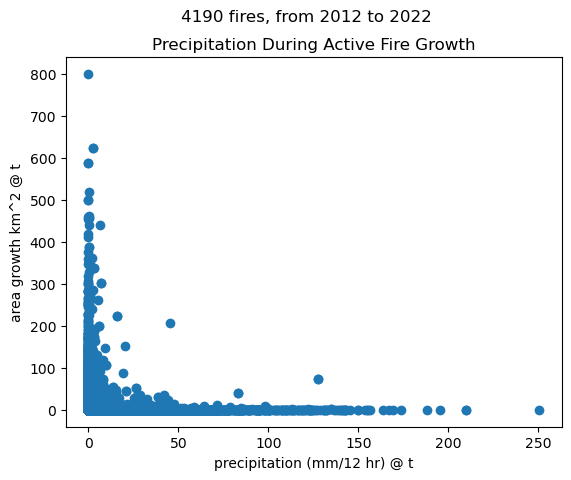

In [12]:
af_mask =  (fires['start_off_12hrs'] >= 0) & (fires['end_off_12hrs'] <= 0)

plt.scatter(y = fires[af_mask].area_growth_at_t_km2, x = fires[af_mask].precipitation)
plt.xlabel("precipitation (mm/12 hr) @ t")
plt.ylabel("area growth km^2 @ t")
plt.title("Precipitation During Active Fire Growth")
plt.suptitle(f"{fires[af_mask].UfireID.nunique()} fires, from {fires[af_mask].t.dt.year.min()} to {fires[af_mask].t.dt.year.max()}")

Text(0.5, 0.98, '4190 fires, from 2012 to 2022')

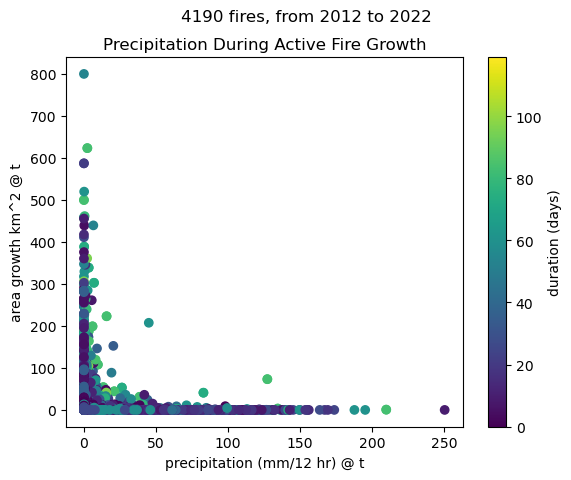

In [13]:
af_mask =  (fires['start_off_12hrs'] >= 0) & (fires['end_off_12hrs'] <= 0)

plt.scatter(y = fires[af_mask].area_growth_at_t_km2, x = fires[af_mask].precipitation, c =  fires[af_mask].duration)
plt.xlabel("precipitation (mm/12 hr) @ t")
plt.ylabel("area growth km^2 @ t")
plt.title("Precipitation During Active Fire Growth")
plt.colorbar(label = "duration (days)")
plt.suptitle(f"{fires[af_mask].UfireID.nunique()} fires, from {fires[af_mask].t.dt.year.min()} to {fires[af_mask].t.dt.year.max()}")

Text(0.5, 0.98, '4190 fires, from 2012 to 2022')

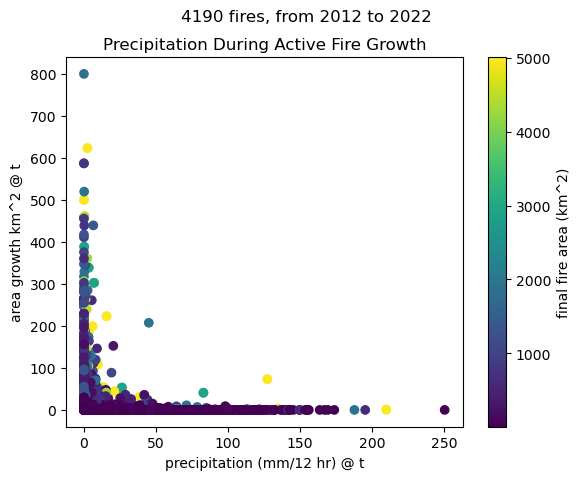

In [14]:
af_mask =  (fires['start_off_12hrs'] >= 0) & (fires['end_off_12hrs'] <= 0)
mutliday = fires.duration > 0

plt.scatter(y = fires[af_mask].area_growth_at_t_km2, x = fires[af_mask].precipitation, c =  fires[af_mask].farea)
plt.xlabel("precipitation (mm/12 hr) @ t")
plt.ylabel("area growth km^2 @ t")
plt.title("Precipitation During Active Fire Growth")
plt.colorbar(label = "final fire area (km^2)")
plt.suptitle(f"{fires[af_mask].UfireID.nunique()} fires, from {fires[af_mask].t.dt.year.min()} to {fires[af_mask].t.dt.year.max()}")

# Zeb's dataset doesn't have the non-spread timesteps, so we don't have the times when firegrowth = 0 in the above plot

In [15]:
#fires.loc[af_mask & (fires.area_growth_at_t_km2.isna()), "area_growth_at_t_km2"] = 0

Text(0.5, 0.98, '4190 fires, from 2012 to 2022')

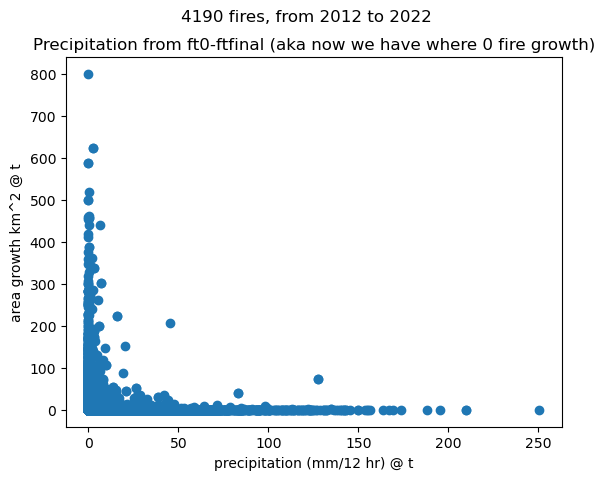

In [16]:
plt.scatter(y = fires[af_mask].area_growth_at_t_km2, x = fires[af_mask].precipitation)
plt.xlabel("precipitation (mm/12 hr) @ t")
plt.ylabel("area growth km^2 @ t")
plt.title("Precipitation from ft0-ftfinal (aka now we have where 0 fire growth)")
plt.suptitle(f"{fires[af_mask].UfireID.nunique()} fires, from {fires[af_mask].t.dt.year.min()} to {fires[af_mask].t.dt.year.max()}")

# fires.loc[:, "precipitation_no_zero"] = fires["precipitation"] + 1
# fires.loc[:, "area_growth_at_t_km2_no_zero"] = fires["area_growth_at_t_km2"] + 1

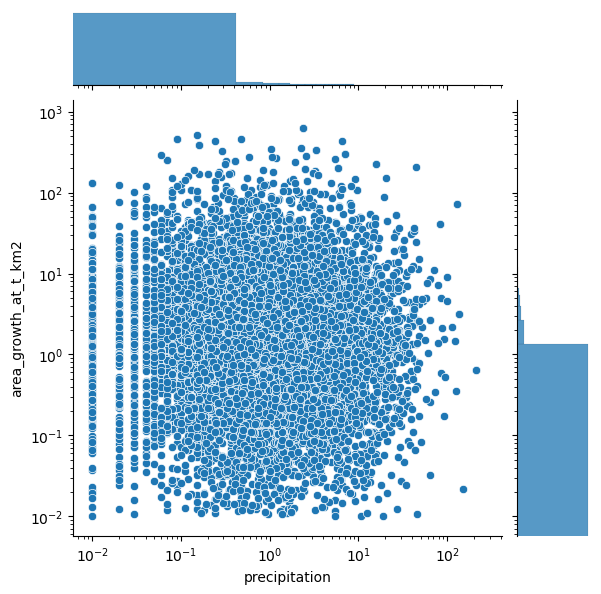

In [17]:
import seaborn as sns

sns.jointplot(data = fires[af_mask], y = "area_growth_at_t_km2", x = "precipitation")
plt.xscale('log')
plt.yscale('log')

<Axes: xlabel='precipitation_no_zero', ylabel='area_growth_at_t_km2_no_zero'>

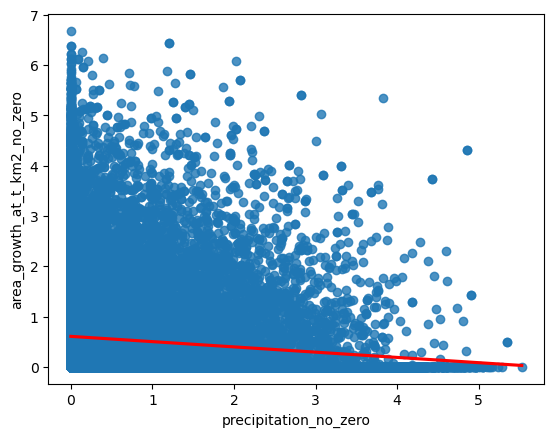

In [18]:
sns.regplot(y = np.log(fires[af_mask].area_growth_at_t_km2_no_zero), x = np.log(fires[af_mask].precipitation_no_zero), ci = None, line_kws=dict(color="r"))

<Axes: xlabel='precipitation', ylabel='area_growth_at_t_km2'>

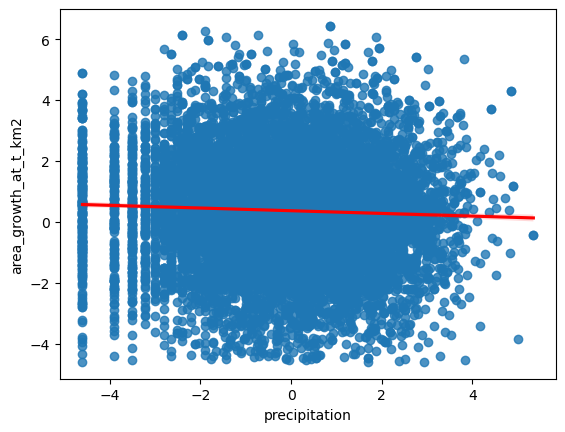

In [19]:
sns.regplot(y = np.log(fires.loc[af_mask & (fires.area_growth_at_t_km2 > 0)  & (fires.precipitation > 0),: ].area_growth_at_t_km2), x = np.log(fires.loc[af_mask & (fires.area_growth_at_t_km2 > 0)  & (fires.precipitation > 0),: ].precipitation), ci = 95, line_kws=dict(color="r"))

#### How many fires ended after precipitation? 

I will look at the distribution of precip 
 - after fires ended (12 hour increment to start out)
 - during fires
 - before fires started (12 hour increment)
 - if ending precip bigger than during precip important? (dunno)





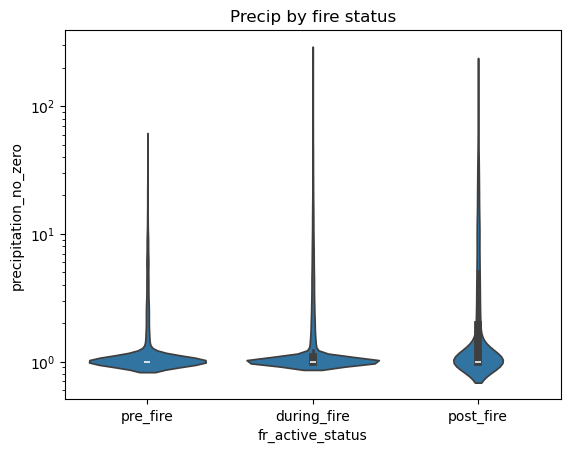

In [20]:
import seaborn as sns

### set up column for easly plotting 

pre_fire_mask = fires.start_off_12hrs == -1 ## conservative, next 12 hours, could expand to 24 because of differences in detection effecientcy
post_fire_mask = fires.end_off_12hrs == 1
multiday = fires.duration > 0 


# fires.loc[pre_fire_mask, "fr_active_status"] = "pre_fire"
# fires.loc[post_fire_mask, "fr_active_status"] = "post_fire"
# fires.loc[af_mask, "fr_active_status"] = "during_fire"


sns.violinplot(data=fires[["fr_active_status", "precipitation_no_zero"]].dropna(), x = "fr_active_status" , y="precipitation_no_zero", log_scale=(False, True))
#sns.violinplot(data=fires[["fr_active_status", "precipitation"]].dropna(), x = "fr_active_status" , y="precipitation")
plt.yscale('log')
plt.title("Precip by fire status")
plt.show()

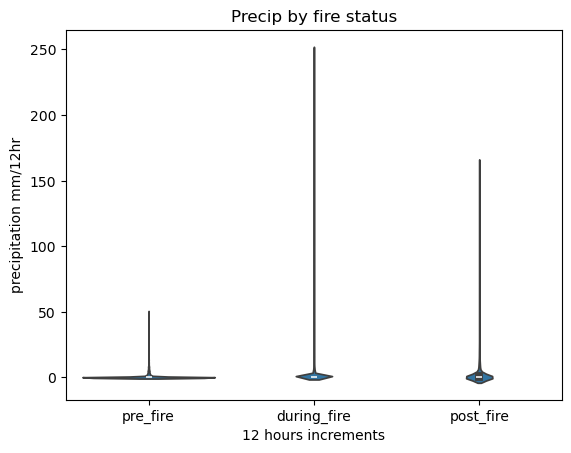

In [21]:
sns.violinplot(data=fires[["fr_active_status", "precipitation"]].dropna(), x = "fr_active_status" , y="precipitation")

plt.title("Precip by fire status")
plt.xlabel("12 hours increments")
plt.ylabel("precipitation mm/12hr")
plt.show()

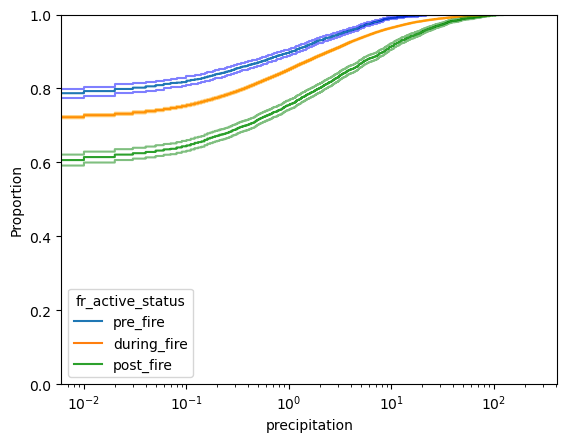

In [22]:
from scipy import stats

res = stats.ecdf(fires[fires.fr_active_status == "during_fire"].precipitation)
res_post = stats.ecdf(fires[fires.fr_active_status == "post_fire"].precipitation)
res_pre = stats.ecdf(fires[fires.fr_active_status == "pre_fire"].precipitation)
ci_df = res.cdf.confidence_interval(confidence_level=0.95)
ci_pf = res_post.cdf.confidence_interval(confidence_level=0.95)
ci_pre = res_pre.cdf.confidence_interval(confidence_level=0.95)

ax = sns.ecdfplot(data=fires[["fr_active_status", "precipitation"]].dropna(),  x="precipitation",  hue = "fr_active_status")
# ax.fill_between(ci_df.low.quantiles, ci_df.low, ci_df.high, 
#                 step='pre', color='orange', alpha=0.5, 
#                 label='95% Confidence Interval')
ci_df.low.plot(ax, color='orange', alpha=0.5)
ci_df.high.plot(ax, color='orange', alpha=0.5)

ci_pf.low.plot(ax, color = "green", alpha=0.5)
ci_pf.high.plot(ax, color = "green", alpha=0.5)

ci_pre.low.plot(ax, color = "blue", alpha=0.5)
ci_pre.high.plot(ax, color = "blue", alpha=0.5)
#sns.ecdfplot(data=fires[["fr_active_status", "precipitation"]].dropna(),  x="precipitation",  color = "gray")
ax.set(xscale="log") 
plt.show()

Difference in precip was t_1 - t_0
 There was a mean of 1.583548903465271 difference in precip in the 12 hours after last fire growth
 50th quantile 0.0
 60th quantile 0.0
 70th quantile 0.01999998651444912
 80th quantile 0.8699998021125793
 90th quantile 5.334999942779536
0.3073985680190931 Percent of fires ended after a positve increase in precip in the 12 hours after the last fire growth detection.


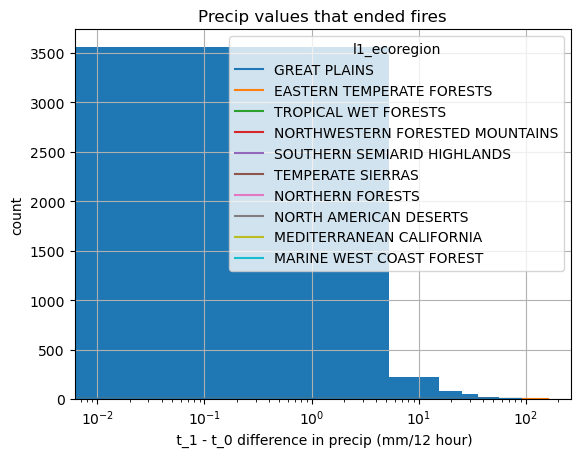

In [23]:
fires.loc[post_fire_mask,:].precip_diff.hist(bins = 25) ## For the 12 hours after the last spread, seems like a a mean 1.58 mm per 12 hours
plt.xlabel( " t_1 - t_0 difference in precip (mm/12 hour)")
plt.ylabel( "count")
print("Difference in precip was t_1 - t_0")
print(f" There was a mean of {fires.loc[post_fire_mask,:].precip_diff.mean()} difference in precip in the 12 hours after last fire growth")

print(f" 50th quantile {fires.loc[post_fire_mask,:].precip_diff.quantile(.5)}")
print(f" 60th quantile {fires.loc[post_fire_mask,:].precip_diff.quantile(.6)}")
print(f" 70th quantile {fires.loc[post_fire_mask,:].precip_diff.quantile(.7)}")
print(f" 80th quantile {fires.loc[post_fire_mask,:].precip_diff.quantile(.8)}")
print(f" 90th quantile {fires.loc[post_fire_mask,:].precip_diff.quantile(.9)}")

fires.loc[post_fire_mask & (fires.precip_diff > 0),"precip_end_event"] = True
fires.loc[post_fire_mask & (fires.precip_diff <= 0),"precip_end_event"] = False

fires.loc[post_fire_mask & (fires.precip_diff == 0),"no_change_end_event"] = True
fires.loc[post_fire_mask & (fires.precip_diff < 0),"no_change_end_event"] = False
fires.loc[post_fire_mask & (fires.precip_diff > 0),"no_change_end_event"] = False

fires.loc[(post_fire_mask & (fires.precip_diff == 0)) & (fires.precipitation == 0), 'zero_precip_at_end'] = True
fires.loc[(post_fire_mask & (fires.precip_diff == 0)) & (fires.precipitation != 0), 'zero_precip_at_end'] = False

fires.loc[(fires.precipitation <= 0.5), "trace_rain"] = True ### look, there is not perfect way to represent trace values. I am going to assume that becuase rain is rare, that I will likely only get 1 value, or a few values, so I don't have to worry about summation issues. 
fires.loc[(fires.precipitation > 0.5), "trace_rain"] = False


fires.loc[post_fire_mask & (fires.precip_diff < 0),"neg_precip_end_event"] = True
fires.loc[post_fire_mask & (fires.precip_diff >= 0),"neg_precip_end_event"] = False

## what about fires that experienced no precip at all? 

def no_precip_at_all(df):
    max_precip = df.precipitation.max()
    if(max_precip == 0):
        df.loc[:, "no_precip_at_all"] = True
    else:
        df.loc[:, "no_precip_at_all"] = False
    return(df)
fires = fires.groupby('UfireID').apply(no_precip_at_all).reset_index(drop = True)

print(f"{len(fires.loc[post_fire_mask & (fires.precip_diff > 0),:].precip_diff) / len(fires.loc[post_fire_mask ,:].precip_diff)} Percent of fires ended after a positve increase in precip in the 12 hours after the last fire growth detection.")
def plot_ecdf_cat(fires, cat):

    #res_list = []
    #ci_list = []
    ax = sns.ecdfplot(data=fires.loc[(fires.precip_end_event == True) & (fires.fr_active_status == "post_fire"),["fr_active_status", "precipitation", cat]].dropna(),  x="precipitation",  hue = cat)
    # for c in fires[cat].unique():
    #     res = stats.ecdf(fires[fires.fr_active_status == c].precipitation)
    #     #res_post = stats.ecdf(fires[fires.fr_active_status == "post_fire"].precipitation)
    #     #res_pre = stats.ecdf(fires[fires.fr_active_status == "pre_fire"].precipitation)
    #     #ci_df = res.cdf.confidence_interval(confidence_level=0.95)
    #     #ci_pf = res_post.cdf.confidence_interval(confidence_level=0.95)
    #    #ci_pre = res_pre.cdf.confidence_interval(confidence_level=0.95)
        
        
    #     # ax.fill_between(ci_df.low.quantiles, ci_df.low, ci_df.high, 
    #     #                 step='pre', color='orange', alpha=0.5, 
    #     #                 label='95% Confidence Interval')
    #     #ci_df.low.plot(ax, color='orange', alpha=0.5)
    #     # ci_df.high.plot(ax, color='orange', alpha=0.5)
        
    #     # ci_pf.low.plot(ax, color = "green", alpha=0.5)
    #     # ci_pf.high.plot(ax, color = "green", alpha=0.5)
        
    #     # ci_pre.low.plot(ax, color = "blue", alpha=0.5)
    #     # ci_pre.high.plot(ax, color = "blue", alpha=0.5)
    #     #sns.ecdfplot(data=fires[["fr_active_status", "precipitation"]].dropna(),  x="precipitation",  color = "gray")
    ax.set(xscale="log") 
    plt.title("Precip values that ended fires")
    plt.show()
plot_ecdf_cat(fires, 'l1_ecoregion')

In [24]:
# Checking the propotion of "no rain during fire at all" and proportion of "no change in fire" that comes from a true zero. 
no_precip = fires.groupby("UfireID").no_precip_at_all.max().reset_index()

print(f'Number of fires that experiences NO PRECIP AT ALL (in the entire record, start and stop) : {len(no_precip[no_precip.no_precip_at_all])} or { (len(no_precip[no_precip.no_precip_at_all])/ len(no_precip)) * 100 } percent.')

Number of fires that experiences NO PRECIP AT ALL (in the entire record, start and stop) : 183 or 4.3675417661097855 percent.


In [25]:
# ax = plt.subplot()
# res.sf.plot(ax)
# #ax.set_xlabel('One-Mile Run Time (minutes)')
# #ax.set_ylabel('Empirical CDF')
# plt.show()


Hard to see from the above plots, but I think that postfire has a higher central tendency than the others. Maybe look at the distributions CI's and use a KSTEST? 



In [26]:
print("70th Quantile for different fire statuses")

print(fires.groupby("fr_active_status").precipitation.quantile(0.7))


print("80th Quantile for different fire statuses")

print(fires.groupby("fr_active_status").precipitation.quantile(0.8))

print("90th Quantile for different fire statuses")

print(fires.groupby("fr_active_status").precipitation.quantile(0.9))



### TO DO KSTEST

70th Quantile for different fire statuses
fr_active_status
during_fire    0.000
post_fire      0.383
pre_fire       0.000
Name: precipitation, dtype: float64
80th Quantile for different fire statuses
fr_active_status
during_fire    0.37
post_fire      1.97
pre_fire       0.03
Name: precipitation, dtype: float64
90th Quantile for different fire statuses
fr_active_status
during_fire    2.470
post_fire      8.471
pre_fire       1.071
Name: precipitation, dtype: float64


# How many fires ended after an *uptick* in precipitation? 

Instead of looking at the raw amount of precipitation after a fire stopped, looking at fires that stopped after an uptick in precip specifically. This is a little scary given the 12-hourly stuff, so may need to consider a rolling difference, or 24 hour difference etc. 

In [27]:
#fires = fires.sjoin(gsp[['GACCName', 'GACCAbbrev','geometry']])

In [28]:
# fires.t = fires.t.astype("datetime64[ns]")
# fires = fires.sort_values(by = ["UfireID", "t"])
# fires["precip_diff"] = fires.groupby("UfireID").precipitation.diff() ## Positive is when the amount of rain goes up, negative down

0.009999990463256836


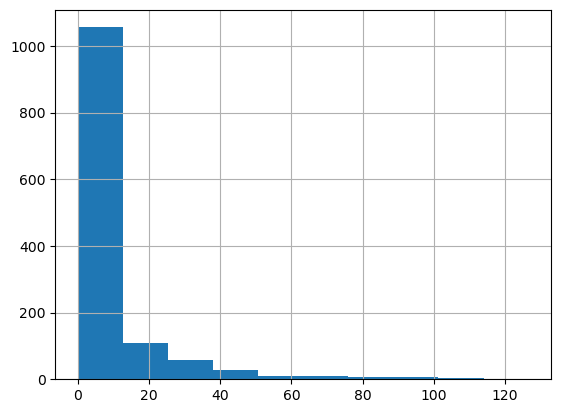

In [29]:
# Of the positives, what was the range in precipitation values? 

fires.loc[post_fire_mask & (fires.precip_diff > 0),:].precip_diff.hist() # I would love to match this to final fire size. I bet there is is trade off!

print(fires.loc[post_fire_mask & (fires.precip_diff > 0),:].precip_diff.min())

In [30]:
# #plt.scatter(fires.loc[post_fire_mask & (fires.precip_diff > 0),:].precip_diff, fires.loc[post_fire_mask & (fires.precip_diff > 0),:].farea)  ## There is, but it's not very informative becasue it's basically the same as farea diff
# final_time = fires.t == fires.end_time

# plt.scatter(fires[post_fire_mask].precipitation, fires[post_fire_mask].farea)

In [31]:
## Percent of fires where weather stayed the same


print(f"{len(fires.loc[post_fire_mask & (fires.precip_diff == 0),:].precip_diff) / len(fires.loc[post_fire_mask ,:].precip_diff)} Percent of fires ended after no change in precip in the 12 hours after the last fire growth detection.")

0.5164677804295943 Percent of fires ended after no change in precip in the 12 hours after the last fire growth detection.


In [32]:
print(f"{len(fires.loc[post_fire_mask & (fires.precip_diff < 0),:].precip_diff) / len(fires.loc[post_fire_mask ,:].precip_diff)} Percent of fires ended after a decrease in precip in the 12 hours after the last fire growth detection.")


print(f" NOTE Percentages coming from {len(fires.loc[post_fire_mask ,:].UfireID.unique())} fires.")

0.17613365155131264 Percent of fires ended after a decrease in precip in the 12 hours after the last fire growth detection.
 NOTE Percentages coming from 4190 fires.


#### Check for uncertainty in the % numbers, pull out by catagory. 

In [33]:
n_iterations = 10000
overall_bootstraps = np.empty(n_iterations)


target_array =fires.loc[post_fire_mask, 'precip_end_event'].values 

for i in range(n_iterations):
    # Resample with replacement
    sample = np.random.choice(target_array, size=len(target_array), replace=True)
    overall_bootstraps[i] = np.mean(sample)

overall_obs = np.mean(target_array)
overall_ci = np.percentile(overall_bootstraps, [2.5, 97.5])

print("--- OVERALL UNCERTAINTY ---")
print(f"Observed Overall Global Proportion: {overall_obs:.1%}")
print(f"95% Confidence Interval:     [{overall_ci[0]:.1%}, {overall_ci[1]:.1%}]\n")

#multiday = fires.duration >0

n_iterations = 10000
overall_bootstraps = np.empty(n_iterations)


target_array =fires[multiday].loc[post_fire_mask, 'precip_end_event'].values 

for i in range(n_iterations):
    # Resample with replacement
    sample = np.random.choice(target_array, size=len(target_array), replace=True)
    overall_bootstraps[i] = np.mean(sample)

overall_obs = np.mean(target_array)
overall_ci = np.percentile(overall_bootstraps, [2.5, 97.5])

print("--- OVERALL UNCERTAINTY ---")
print(f"Observed Overall multi-day Global Proportion: {overall_obs:.1%}")
print(f"95% Confidence Interval:     [{overall_ci[0]:.1%}, {overall_ci[1]:.1%}]\n")


# Abstracting to 

--- OVERALL UNCERTAINTY ---
Observed Overall Global Proportion: 30.7%
95% Confidence Interval:     [29.3%, 32.1%]

--- OVERALL UNCERTAINTY ---
Observed Overall multi-day Global Proportion: 31.7%
95% Confidence Interval:     [30.2%, 33.2%]



Looking at the percentage (and confidence intervals) on a catagorical basis. ecoregions and GACCS

In [34]:
### read in the gacs
gsp = gpd.read_file("/home/jovyan/Preparedness_level/GACC_borders/National_GACC_Boundaries.shp")
gsp = gsp.to_crs("EPSG:4326")


# CONUS bounding box
x_min, x_max = -128.95, -66.69 
y_min, y_max = 22.97, 50.0

# Crop using the .cx indexer
# This keeps any geometry that intersects with this bounding box. We are dropping Alaska, HI, Puerto Rico & Guam 
gsp = gsp.cx[x_min:x_max, y_min:y_max]

gsp = gsp[gsp.GlobalID != 'cfbdafaf-8f3a-4c69-b8c9-6bb82abbd2d9']

gsp = gsp.dissolve(by='GACCAbbrev').reset_index()

gsp.loc[:, "Lat"] = gsp.centroid.y
gsp.loc[:, "Lon"] = gsp.centroid.x



def calc_percent_end(df, cat, n_iterations = 100, var = ['precip_end_event'] ):
    post_fire_mask = df.end_off_12hrs == 1
    for v in var:
        for c in df[cat].unique():
            print(f"using {n_iterations} for bootstrapping")
            overall_bootstraps = np.empty(n_iterations)
            
            target_array =df.loc[post_fire_mask & (df[cat] == c), v].values 
        
            for i in range(n_iterations):
                # Resample with replacement
                sample = np.random.choice(target_array, size=len(target_array), replace=True)
                overall_bootstraps[i] = np.mean(sample)
            
            overall_obs = np.mean(target_array)
            overall_ci = np.percentile(overall_bootstraps, [2.5, 97.5])
            
        
            print("--- OVERALL UNCERTAINTY ---")
            print(f"{c} Observed Overall Proportion when {v} (N = {df[post_fire_mask & (df[cat] == c)].UfireID.nunique()}): {overall_obs:.1%}")
            print(f"{c} 95% Confidence Interval:     [{overall_ci[0]:.1%}, {overall_ci[1]:.1%}]\n")

def calc_percent_end_save(df, cat, n_iterations = 100, var = ['precip_end_event'], path = "/home/jovyan/Precipitation_paper/gen_data/", cat_map = gsp ):
    print(f"using {n_iterations} for bootstrapping")
    post_fire_mask = df.end_off_12hrs == 1
    #data_df = pd.DataFrame([])
    # data_df = pd.DataFrame({
    #     'region': df[cat].unique(),
    #     "ci_025": np.nan, 
    #     "ci_975": np.nan, 
    #     "uncert_len": np.nan, 
    #     "sample_size": np.nan
        
    #     # 'x': df["Lat"], # Longitude
    #     # 'y': df["Lon"],      # Latitude
    #     #'sample_size': [, 420, 610],
        
    #     # Fractions for each condition (should sum to 1.0 per row)
    #     #Cond_A': [0.50, 0.40, 0.20],
    #     #'Cond_B': [0.30, 0.40, 0.50],
    #     #'Cond_C': [0.20, 0.20, 0.30],
        
    #     # Uncertainties for each condition
    #     #'Unc_A': [0.05, 0.04, 0.03],
    #     #'Unc_B': [0.03, 0.05, 0.08],
    #     #'Unc_C': [0.02, 0.02, 0.05]
    # })
    results = []
    for v in var:
        # data_df.loc[:, v] = np.nan
        for c in df[cat].unique():
            
            overall_bootstraps = np.empty(n_iterations)
            
            target_array =df.loc[post_fire_mask & (df[cat] == c), v].values 
        
            for i in range(n_iterations):
                # Resample with replacement
                sample = np.random.choice(target_array, size=len(target_array), replace=True)
                overall_bootstraps[i] = np.mean(sample)
            
            overall_obs = np.mean(target_array)
            overall_ci = np.percentile(overall_bootstraps, [2.5, 97.5])
            # print(data_df.loc[(data_df.region == c))

            # data_df.loc[(data_df.region == c), v] == float(overall_obs) # Mean percentage
            # data_df.loc[(data_df.region == c), "ci_025"] = float(overall_ci[0])
            # data_df.loc[(data_df.region == c), "ci_975"] = float(overall_ci[1])
            # data_df.loc[(data_df.region == c), "uncert_len"] = (float(overall_ci[1]) - float(overall_ci[0]))
            # data_df.loc[(data_df.region == c), "sample_size"] = df[post_fire_mask & (df[cat] == c)].UfireID.nunique()
            results.append({
                'region': c,
                v: float(overall_obs), # Your mean percentage
                'ci_025': float(overall_ci[0]),
                'ci_975': float(overall_ci[1]),
                'uncert_len': float(overall_ci[1]) - float(overall_ci[0]),
                'sample_size': df[post_fire_mask & (df[cat] == c)].UfireID.nunique()
            })
            print("--- OVERALL UNCERTAINTY ---")
            print(f"{c} Observed Overall Proportion when {v} (N = {df[post_fire_mask & (df[cat] == c)].UfireID.nunique()}): {overall_obs:.1%}")
            print(f"{c} 95% Confidence Interval:     [{overall_ci[0]:.1%}, {overall_ci[1]:.1%}]\n")
    
    data_df = pd.DataFrame(results)
    current_date = datetime.datetime.now().strftime("%Y-%m-%d")
    data_df.to_csv(path + f'percent_breakdown_{cat}_{current_date}_{n_iterations}.csv')
        

#calc_percent_end(fires, cat = 'GACCName', var = ['precip_end_event', 'no_change_end_event', 'neg_precip_end_event'], n_iterations = 10000) 

In [35]:
calc_percent_end_save(fires, cat = 'GACCAbbrev', var = ['precip_end_event', 'no_change_end_event', 'neg_precip_end_event'], n_iterations = 10000)

using 10000 for bootstrapping
--- OVERALL UNCERTAINTY ---
SACC Observed Overall Proportion when precip_end_event (N = 1576): 29.9%
SACC 95% Confidence Interval:     [27.7%, 32.2%]

--- OVERALL UNCERTAINTY ---
RMCC Observed Overall Proportion when precip_end_event (N = 268): 33.2%
RMCC 95% Confidence Interval:     [27.6%, 38.8%]

--- OVERALL UNCERTAINTY ---
EACC Observed Overall Proportion when precip_end_event (N = 92): 37.0%
EACC 95% Confidence Interval:     [27.2%, 46.7%]

--- OVERALL UNCERTAINTY ---
SWCC Observed Overall Proportion when precip_end_event (N = 518): 23.4%
SWCC 95% Confidence Interval:     [19.7%, 27.2%]

--- OVERALL UNCERTAINTY ---
NWCC Observed Overall Proportion when precip_end_event (N = 464): 30.6%
NWCC 95% Confidence Interval:     [26.5%, 34.7%]

--- OVERALL UNCERTAINTY ---
NRCC Observed Overall Proportion when precip_end_event (N = 390): 50.5%
NRCC 95% Confidence Interval:     [45.6%, 55.4%]

--- OVERALL UNCERTAINTY ---
OSCC Observed Overall Proportion when prec

In [36]:
calc_percent_end(fires, cat = 'l1_ecoregion', n_iterations = 10000)  

using 10000 for bootstrapping
--- OVERALL UNCERTAINTY ---
GREAT PLAINS Observed Overall Proportion when precip_end_event (N = 594): 26.8%
GREAT PLAINS 95% Confidence Interval:     [23.2%, 30.3%]

using 10000 for bootstrapping
--- OVERALL UNCERTAINTY ---
EASTERN TEMPERATE FORESTS Observed Overall Proportion when precip_end_event (N = 1250): 31.4%
EASTERN TEMPERATE FORESTS 95% Confidence Interval:     [28.9%, 34.1%]

using 10000 for bootstrapping
--- OVERALL UNCERTAINTY ---
TROPICAL WET FORESTS Observed Overall Proportion when precip_end_event (N = 59): 35.6%
TROPICAL WET FORESTS 95% Confidence Interval:     [23.7%, 47.5%]

using 10000 for bootstrapping
--- OVERALL UNCERTAINTY ---
SOUTHERN SEMIARID HIGHLANDS Observed Overall Proportion when precip_end_event (N = 91): 26.4%
SOUTHERN SEMIARID HIGHLANDS 95% Confidence Interval:     [17.6%, 36.3%]

using 10000 for bootstrapping
--- OVERALL UNCERTAINTY ---
NORTH AMERICAN DESERTS Observed Overall Proportion when precip_end_event (N = 583): 24.

In [37]:
# Fix columsn taht should be constans on a per-id basis


#fires_gacc = fires_gacc.groupby("UfireID").apply(per_id_constants, cols = ["year", "l1_ecoregion", 	"centroid", "farea", 'duration', 'GACCName', 'GACCAbbrev']).reset_index(drop = True)

In [38]:
### Check if this works beter for multi-day fires

# Look at fire-stopping precip by GACCS and by ecoregion

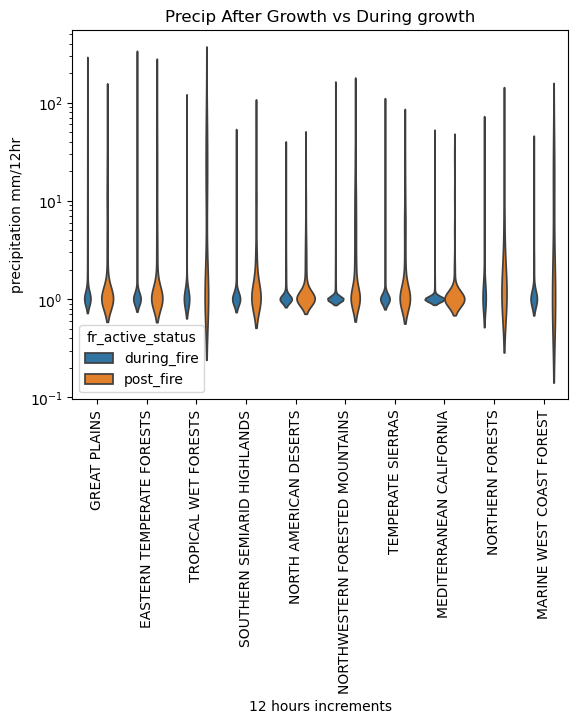

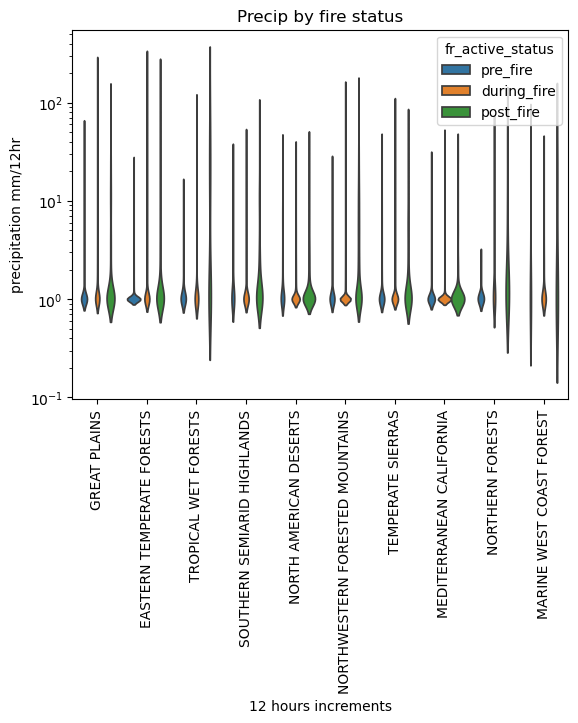

In [39]:
just_post_and_during_mask = fires.fr_active_status.isin(['during_fire', 'post_fire'])

#
sns.violinplot(data=fires.loc[just_post_and_during_mask, ["fr_active_status", 'precipitation_no_zero', "l1_ecoregion"]].dropna(), x = "l1_ecoregion" , y='precipitation_no_zero', hue = "fr_active_status", inner = None, log_scale = [False, True])

plt.title("Precip After Growth vs During growth")
plt.xlabel("12 hours increments")
plt.ylabel("precipitation mm/12hr")
plt.xticks(rotation=90)
plt.show()


just_post_and_during_mask = fires.fr_active_status.isin(['during_fire', 'post_fire'])

#
sns.violinplot(data=fires.loc[:, ["fr_active_status", 'precipitation_no_zero', "l1_ecoregion"]].dropna(), x = "l1_ecoregion" , y='precipitation_no_zero', hue = "fr_active_status", log_scale = [False, True], inner = None)

plt.title("Precip by fire status")
plt.xlabel("12 hours increments")
plt.ylabel("precipitation mm/12hr")
plt.xticks(rotation=90)
plt.show()




# just_post_and_during_mask = fires_gacc.fr_active_status.isin(['during_fire', 'post_fire'])

# #
# sns.violinplot(data=fires_gacc.loc[just_post_and_during_mask, ["fr_active_status", 'precipitation_no_zero', "l1_ecoregion"]].dropna(), x = "l1_ecoregion" , y='precipitation_no_zero', hue = "fr_active_status", inner = None, log_scale = [False, True])

# plt.title("Precip After Growth vs During growth")
# plt.xlabel("12 hours increments")
# plt.ylabel("precipitation mm/12hr")
# plt.xticks(rotation=90)
# plt.show()


# just_post_and_during_mask = fires_gacc.fr_active_status.isin(['during_fire', 'post_fire'])

# #
# sns.violinplot(data=fires_gacc.loc[:, ["fr_active_status", 'precipitation_no_zero', "l1_ecoregion"]].dropna(), x = "l1_ecoregion" , y='precipitation_no_zero', hue = "fr_active_status", log_scale = [False, True], inner = None)

# plt.title("Precip by fire status")
# plt.xlabel("12 hours increments")
# plt.ylabel("precipitation mm/12hr")
# plt.xticks(rotation=90)
# plt.show()

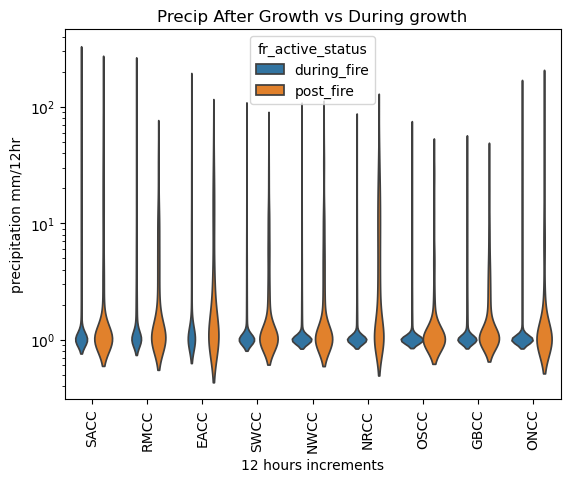

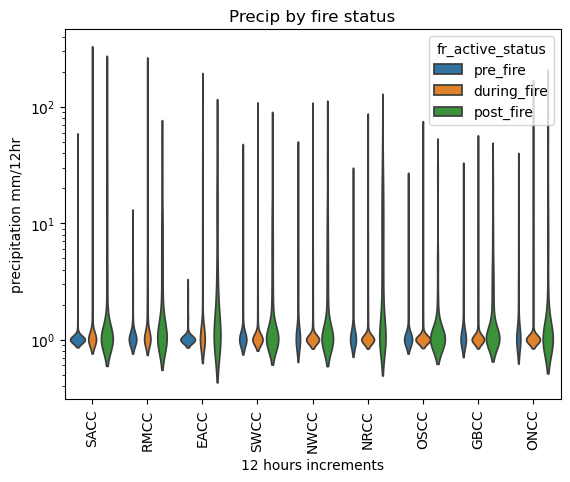

In [40]:

just_post_and_during_mask = fires.fr_active_status.isin(['during_fire', 'post_fire'])

#
sns.violinplot(data=fires.loc[just_post_and_during_mask, ["fr_active_status", 'precipitation_no_zero', "GACCAbbrev"]].dropna(), x = "GACCAbbrev" , y='precipitation_no_zero', hue = "fr_active_status", inner = None, log_scale = [False, True])

plt.title("Precip After Growth vs During growth")
plt.xlabel("12 hours increments")
plt.ylabel("precipitation mm/12hr")
plt.xticks(rotation=90)
plt.show()


just_post_and_during_mask = fires.fr_active_status.isin(['during_fire', 'post_fire'])

#
sns.violinplot(data=fires.loc[:, ["fr_active_status", 'precipitation_no_zero', "GACCAbbrev"]].dropna(), x = "GACCAbbrev" , y='precipitation_no_zero', hue = "fr_active_status", log_scale = [False, True], inner = None)

plt.title("Precip by fire status")
plt.xlabel("12 hours increments")
plt.ylabel("precipitation mm/12hr")
plt.xticks(rotation=90)
plt.show()

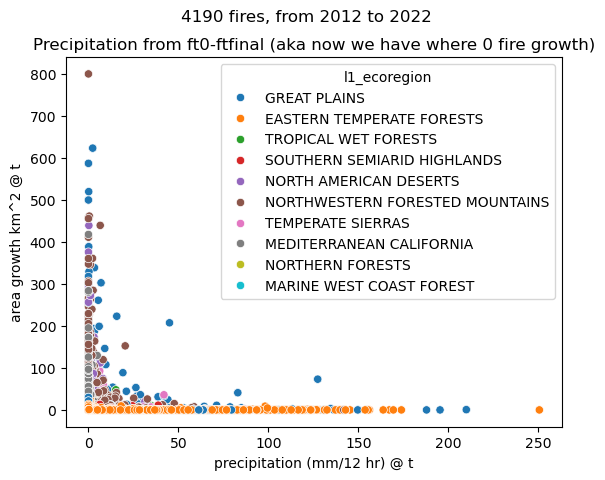

In [41]:
### Why i smatplotlib so weird about color mapping?

# levels, categories = pd.factorize(fires[af_mask].fr_active_status)
# colors = [plt.cm.tab10(i) for i in levels] # using the "tab10" colormap

sns.scatterplot(data = fires[af_mask], y = 'area_growth_at_t_km2', x = "precipitation", hue = "l1_ecoregion" )
#plt.scatter(y = fires[af_mask].area_growth_at_t_km2, x = fires[af_mask].precipitation, c = colors)
plt.xlabel("precipitation (mm/12 hr) @ t")
plt.ylabel("area growth km^2 @ t")
plt.title("Precipitation from ft0-ftfinal (aka now we have where 0 fire growth)")
plt.suptitle(f"{fires[af_mask].UfireID.nunique()} fires, from {fires[af_mask].t.dt.year.min()} to {fires[af_mask].t.dt.year.max()}")
plt.show()

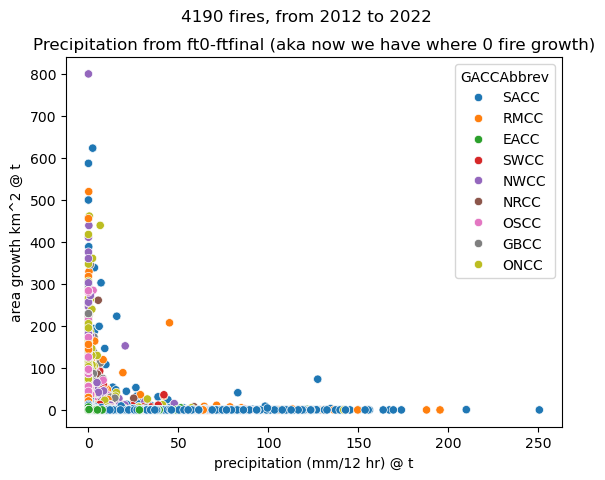

In [42]:

sns.scatterplot(data = fires[af_mask], y = 'area_growth_at_t_km2', x = "precipitation", hue = 'GACCAbbrev')
#plt.scatter(y = fires[af_mask].area_growth_at_t_km2, x = fires[af_mask].precipitation, c = colors)
plt.xlabel("precipitation (mm/12 hr) @ t")
plt.ylabel("area growth km^2 @ t")
plt.title("Precipitation from ft0-ftfinal (aka now we have where 0 fire growth)")
plt.suptitle(f"{fires[af_mask].UfireID.nunique()} fires, from {fires[af_mask].t.dt.year.min()} to {fires[af_mask].t.dt.year.max()}")
plt.show()


In [43]:

# cat_var = "l1_ecoregion"
# for ec in fires.loc[af_mask, cat_var].unique():
#     sns.lmplot(data = fires.loc[af_mask & (fires[cat_var] == ec), :], x = "precipitation_no_zero", y = 'area_growth_at_t_km2', 
#            lowess = True, ci=None,  line_kws=dict(color="r"))
#     # plt.xlabel("precipitation (mm/12 hr) @ t")
#     plt.ylabel("area growth km^2 @ t")
#     plt.title(f"{ec}")
#     plt.suptitle(f"{fires.loc[af_mask & (fires[cat_var] == ec), :].UfireID.nunique()} fires, from {fires.loc[af_mask & (fires[cat_var] == ec), :].t.dt.year.min()} to {fires.loc[af_mask & (fires[cat_var] == ec), :].t.dt.year.max()}")
#     plt.show()
    
# sns.lmplot(data = fires.loc[af_mask & (fires[cat_var] == ec), :], x = "precipitation", y = 'area_growth_at_t_km2', 
#        order=2, ci=None, col = "l1_ecoregion")

# Look at the timeseries of raw (un anomolied) precip stoppages through time

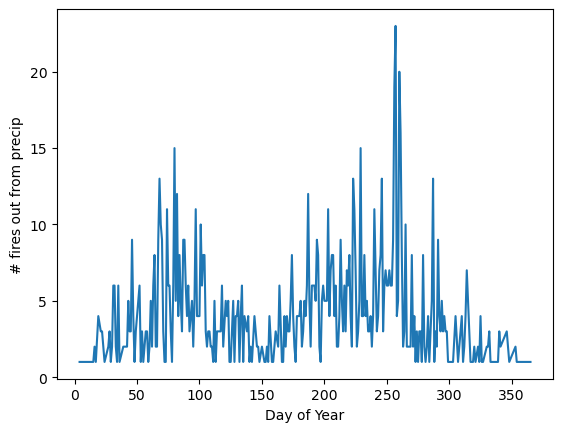

In [44]:
fires.loc[:, "doy"] = fires.t.astype("datetime64[ns]").dt.dayofyear

timeline = fires[fires.precip_end_event== True].groupby(["doy"]).UfireID.count().reset_index()

plt.plot(timeline.doy, timeline.UfireID)
plt.ylabel("# fires out from precip")
plt.xlabel("Day of Year")
plt.show()

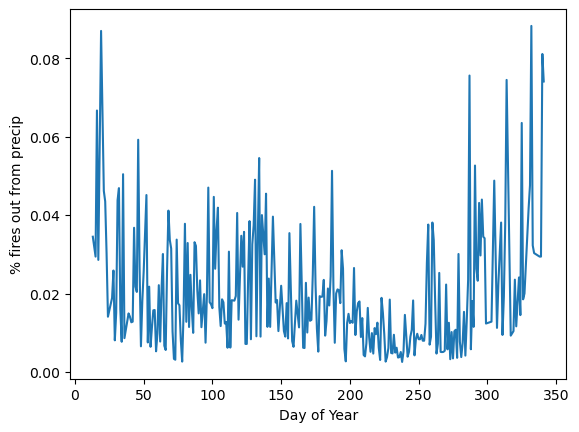

In [45]:
fires.loc[:, "doy"] = fires.t.astype("datetime64[ns]").dt.dayofyear

timeline_total_fires = fires[af_mask].groupby(["doy"]).UfireID.count().reset_index()
timeline_total_fires = timeline_total_fires.rename(columns= {"UfireID": "total_active_fires"})
timeline = timeline.merge(timeline_total_fires, on = "doy")


no_winter = (timeline.doy > 10) & (timeline.doy < 345)

plt.plot(timeline[no_winter].doy, timeline[no_winter].UfireID / timeline[no_winter].total_active_fires)
plt.ylabel("% fires out from precip")
plt.xlabel("Day of Year")
plt.show()

In [46]:
# How many are night endings vs day endings? 


print(f"Of the {fires.UfireID.nunique()} total fires: \n {fires[(fires.t == fires.end_time) & (fires.t.dt.hour == 12)].UfireID.nunique()} ended during a 12 hour, or AMPM growth increment. \n {fires[(fires.t == fires.end_time) & (fires.t.dt.hour == 0)].UfireID.nunique()} ended during the 0th hour overpass or PMAM growth increment")

print(f"Of the multi-day {fires[multiday].UfireID.nunique()} total fires: \n {fires[multiday & (fires.t == fires.end_time) & (fires.t.dt.hour == 12)].UfireID.nunique()} ended during a 12 hour, or AMPM growth increment. \n {fires[multiday & (fires.t == fires.end_time) & (fires.t.dt.hour == 0)].UfireID.nunique()} ended during the 0th hour overpass or PMAM growth increment")

# fires.loc[fires.end_time.astype("datetime64[ns]").dt.hour == 12, "AMPM_end"] = True
# fires.loc[fires.end_time.astype("datetime64[ns]").dt.hour == 0 , "AMPM_end"] = False

Of the 4190 total fires: 
 2690 ended during a 12 hour, or AMPM growth increment. 
 1500 ended during the 0th hour overpass or PMAM growth increment
Of the multi-day 3693 total fires: 
 2229 ended during a 12 hour, or AMPM growth increment. 
 1464 ended during the 0th hour overpass or PMAM growth increment


From what I can see, there is more rain during the PMAM aka afternoon growth increment compared to the morning growth increment


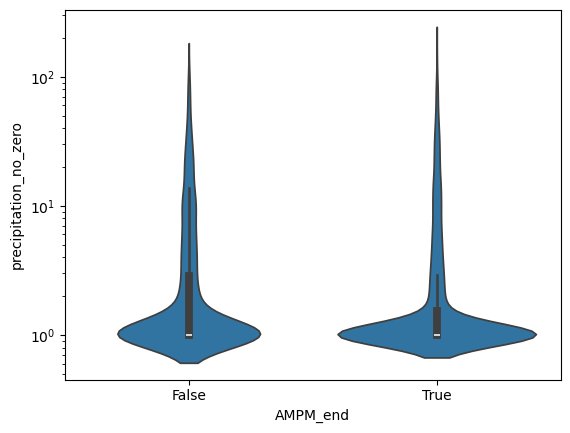

In [47]:
sns.violinplot(data = fires[post_fire_mask], y = "precipitation_no_zero", x = "AMPM_end", log_scale = [False, True])
print("From what I can see, there is more rain during the PMAM aka afternoon growth increment compared to the morning growth increment")

## Plotting the percentages as a donut plot

In [48]:
# import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
percent_data = pd.read_csv("gen_data/percent_breakdown_GACCAbbrev_2026-07-13_10000.csv")

In [49]:
percent_data_reorg = percent_data
percent_data_reorg = percent_data_reorg.drop(columns=['ci_025', 'ci_975',	'uncert_len'])

percent_data_reorg.loc[percent_data_reorg.no_change_end_event.isna() & (percent_data_reorg.neg_precip_end_event.isna()), "no_change_end_event"] = percent_data_reorg[~percent_data_reorg.no_change_end_event.isna()].no_change_end_event.values

percent_data_reorg.loc[percent_data_reorg.neg_precip_end_event.isna() & (~percent_data_reorg.no_change_end_event.isna()) & (~percent_data_reorg.precip_end_event.isna()), "neg_precip_end_event"] = percent_data_reorg[~percent_data_reorg.neg_precip_end_event.isna()].neg_precip_end_event.values
percent_data_reorg = percent_data_reorg.dropna()

percent_data_reorg.loc[:, "unc_precip_end_event"] = percent_data[~percent_data.precip_end_event.isna()].uncert_len.values
percent_data_reorg.loc[:, "unc_no_change_end_event"] = percent_data[~percent_data.no_change_end_event.isna()].uncert_len.values
percent_data_reorg.loc[:, "unc_neg_precip_end_event"] = percent_data[~percent_data.neg_precip_end_event.isna()].uncert_len.values


## Read in the GACC shapefile to get centroids and plot. 
percent_data_reorg.loc[:, "GACCAbbrev"] = percent_data_reorg.region.astype('str').values

percent_data_reorg = percent_data_reorg.merge(gsp[['GACCAbbrev', 'Lat', 'Lon']], on = 'GACCAbbrev')


In [50]:
# # ==========================================
# # 1. Helper function to draw a custom donut
# # ==========================================
def draw_donut_on_map(ax, x, y, fractions, uncertainties, colors, sample_size, radius=0.5):
    """
    Draws a donut chart with uncertainty bars on an existing matplotlib axis.
    
    x, y: coordinates for the center of the donut
    fractions: list of proportions (should sum to 1)
    uncertainties: list of +/- uncertainties for each fraction
    colors: list of colors for the main donut sections
    sample_size: integer to display in the center
    radius: base radius of the donut
    """
    # Define widths
    donut_width = radius * 0.4
    uncertainty_width = radius * 0.15
    inner_radius = radius - donut_width
    outer_radius = radius
    uncertainty_radius = radius + uncertainty_width
    
    # Calculate angles
    starts = []
    ends = []
    current_angle = 0
    for frac in fractions:
        angle = frac * 360
        starts.append(current_angle)
        ends.append(current_angle + angle)
        current_angle += angle
        
    # Draw the wedges
    for i in range(len(fractions)):
        # Main condition wedge
        main_wedge = Wedge((x, y), outer_radius, starts[i], ends[i], 
                           width=donut_width, facecolor=colors[i], edgecolor='white', lw=1, zorder=10)
        ax.add_patch(main_wedge)
        
        # Uncertainty wedge (grey bar on the edge)
        # Convert uncertainty (fraction of total) to degrees
        unc_degrees = uncertainties[i] * 360
        mid_angle = ends[i] #(starts[i] + ends[i]) / 2
        
        unc_wedge = Wedge((x, y), uncertainty_radius, 
                          mid_angle - unc_degrees, mid_angle + unc_degrees, 
                          width=uncertainty_width, facecolor='grey', alpha=0.7, zorder=9)
        ax.add_patch(unc_wedge)
        
    # Add sample size text in the center
    ax.text(x, y, f'{sample_size}', ha='center', va='center', 
            fontsize=8, fontweight='bold', zorder=11)

# # ==========================================
# # 2. Setup Dummy Map and Data
# # ==========================================
# # Load a low-resolution world map from geopandas
# #world = gpd.read_file(gpd.datasets.get_path('https://www.naturalearthdata.com/downloads/110m-cultural-vectors/'))

# # Let's filter to just North America for this example
# regions = gsp

# # Create some dummy data for each region
# np.random.seed(42)
# data = []
# for idx, row in regions.iterrows():
#     # Only put donuts on a few large regions to avoid crowding
#     #if row['name'] in ['United States of America', 'Canada', 'Mexico']:
#     centroid = row.geometry.centroid
#     data.append({
#         'name': row['GACCAbbrev'],
#         'x': centroid.x,
#         'y': centroid.y,
#         'fractions': [0.5, 0.3, 0.2],               # Proportions of conditions
#         'uncertainties': [0.05, 0.03, 0.08],        # +/- uncertainty
#         'sample_size': np.random.randint(100, 1000) # Random sample size
#     })

# # ==========================================
# # 3. Plotting
# # ==========================================
# fig, ax = plt.subplots(figsize=(12, 10))
# ax.set_aspect('equal')

# # Plot the base map
# regions.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.5)

# # Colors for our 3 conditions
# condition_colors = ['#ff9999', '#66b3ff', '#99ff99']

# # Draw a donut for each region in our data
# for item in data:
#     # Scale radius depending on your map's coordinate system (degrees here)
#     draw_donut_on_map(ax, item['x'], item['y'], 
#                       item['fractions'], item['uncertainties'], 
#                       condition_colors, item['sample_size'], radius=6.0)

# # Clean up axes
# ax.set_title("Regional Conditions with Uncertainty", fontsize=16)
# ax.set_xlim(-170, -50)
# ax.set_ylim(10, 85)
# plt.axis('off')

# plt.tight_layout()
# plt.show()

(np.float64(-170.0), np.float64(-50.0), np.float64(10.0), np.float64(85.0))

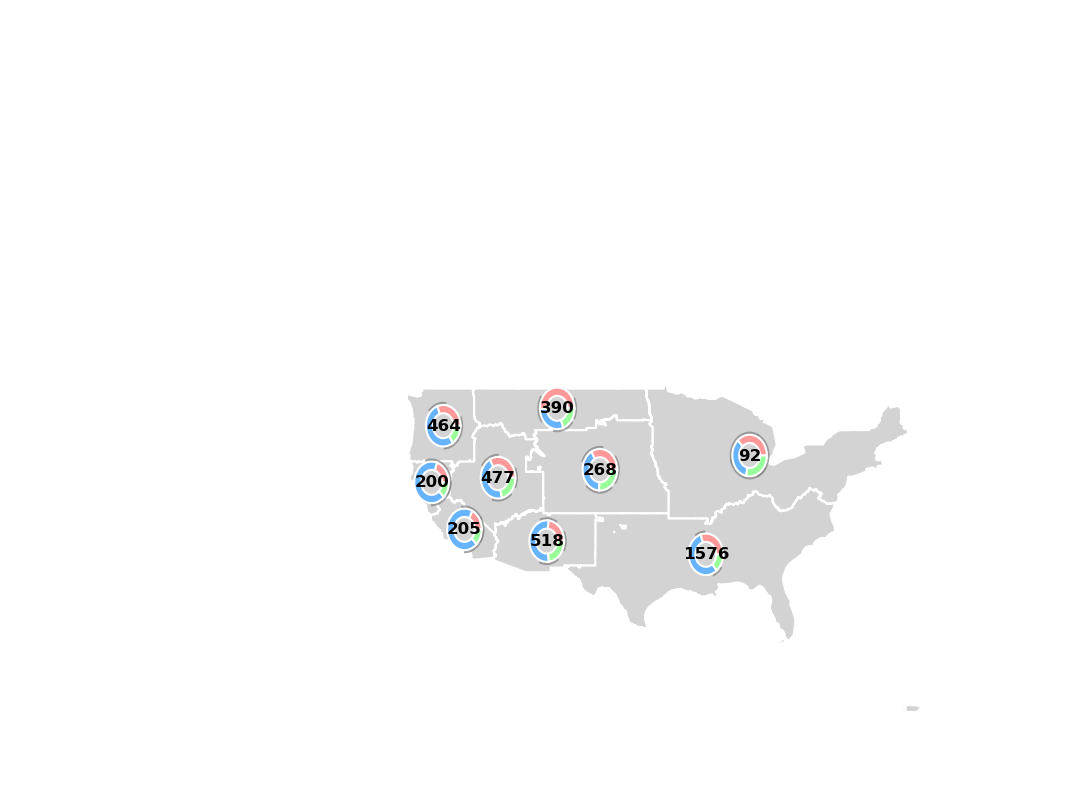

In [51]:
def set_slide_style(aspect_ratio='16:9', base_fontsize=14):
    """
    Configures matplotlib global settings for slide exports.
    """
    # Define standard figure sizes (in inches) based on aspect ratios
    # PowerPoint default widescreen is usually 13.33 x 7.5 inches, 
    # but 10 x 5.625 or 12 x 6.75 scales nicely for matplotlib.
    sizes = {
        '16:9': (12.0, 6.75),
        '4:3':  (10.0, 7.5),
        'square': (8.0, 8.0)
    }
    
    figsize = sizes.get(aspect_ratio, sizes['16:9'])
    
    # Update matplotlib's global rcParams
    plt.rcParams.update({
        # Figure properties
        'figure.figsize': figsize,
        'figure.dpi': 150,           # Good for viewing on screen
        'savefig.dpi': 300,          # High resolution for exporting
        'savefig.bbox': 'tight',     # Removes excess white space around the edge
        'savefig.transparent': True, # Transparent background is often nice for slides
        
        # Font properties
        'font.family': 'sans-serif', # Sans-serif reads better on screens
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': base_fontsize,
        'axes.titlesize': base_fontsize + 4, # Make titles a bit bigger
        'axes.labelsize': base_fontsize + 2,
        'xtick.labelsize': base_fontsize,
        'ytick.labelsize': base_fontsize,
        'legend.fontsize': base_fontsize,
        
        # Line and marker properties
        'lines.linewidth': 2.0,
        'lines.markersize': 8
    })
    
    return figsize




# data_df = pd.DataFrame({
#     'region': ['United States of America', 'Canada', 'Mexico'],
#     'x': [-95.71, -106.34, -102.55], # Longitude
#     'y': [37.09, 56.13, 23.63],      # Latitude
#     'sample_size': [850, 420, 610],
    
#     # Fractions for each condition (should sum to 1.0 per row)
#     'Cond_A': [0.50, 0.40, 0.20],
#     'Cond_B': [0.30, 0.40, 0.50],
#     'Cond_C': [0.20, 0.20, 0.30],
    
#     # Uncertainties for each condition
#     'Unc_A': [0.05, 0.04, 0.03],
#     'Unc_B': [0.03, 0.05, 0.08],
#     'Unc_C': [0.02, 0.02, 0.05]
# })



# Apply standard slide styling
set_slide_style(aspect_ratio='16:9', base_fontsize=6)

fig, ax = plt.subplots()
ax.set_aspect('equal')

# 1. Plot the base map
#world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
regions = gsp[gsp.GACCAbbrev.isin(["EACC", 'GBCC', 'NRCC', 'NWCC', 'ONCC', 'OSCC', 'RMCC', 'SACC', 'SWCC'])]
regions.plot(ax=ax, color='lightgrey', edgecolor='white')

# 2. Define colors and column mappings
condition_colors = ['#ff9999', '#66b3ff', '#99ff99']
condition_cols = ['precip_end_event', 'no_change_end_event', 'neg_precip_end_event']
uncertainty_cols = ['unc_precip_end_event', 'unc_no_change_end_event', 'unc_neg_precip_end_event']

percent_data_reorg.loc[percent_data_reorg.GACCAbbrev == "ONCC", "Lat"] = gsp[gsp.GACCAbbrev == "ONCC"].centroid.y.values
percent_data_reorg.loc[percent_data_reorg.GACCAbbrev == "ONCC", "Lon"] = gsp[gsp.GACCAbbrev == "ONCC"].centroid.x.values

# 3. Iterate over the DataFrame to draw the donuts
for index, row in percent_data_reorg.iterrows():
    # Extract the values across the specific columns and convert to lists
    fractions = row[condition_cols].tolist()
    uncertainties = row[uncertainty_cols].tolist()
    
    draw_donut_on_map(
        ax=ax, 
        x=row['Lon'], 
        y=row['Lat'], 
        fractions=fractions, 
        uncertainties=uncertainties, 
        colors=condition_colors, 
        sample_size=row['sample_size'], 
        radius=2 # Adjust radius based on map scale
    )

# Clean up map bounds
ax.set_xlim(-170, -50)
ax.set_ylim(10, 85)
plt.axis('off')